# Random Walk Metropolis — Gold standard pour un modèle MA(2) hiérarchique

Ce notebook construit le **gold standard non-ABC**.

## Modèle

L'article (supplément, Section 10) considère un MA(2) hiérarchique avec $n$ séries parallèles :

$$x_j(t) = y_{j,t} + \mu_{j,1}\,y_{j,t-1} + \mu_{j,2}\,y_{j,t-2},\qquad y_{j,t} \sim \mathcal{N}(0, \sigma_j^2)$$

avec les dépendances hiérarchiques :

- $(\beta_{j,1}, \beta_{j,2}, 1-\beta_{j,1}-\beta_{j,2}) \sim \mathrm{Dir}(\alpha)$,   où $\mu_{j,1}=\beta_{j,1}-\beta_{j,2}$ et $\mu_{j,2}=2(\beta_{j,1}+\beta_{j,2})-1$
- $\sigma_j^2 \sim \mathrm{IG}(\varsigma_1,\varsigma_2)$
- $\alpha \sim \mathrm{Exp}(1)^{\otimes 3}$, $\varsigma \sim \mathrm{HalfCauchy}(1)^{\otimes 2}$

## Pourquoi RWM est un gold standard

La vraisemblance du MA(2) est **tractable** (modèle gaussien, covariance bande). RWM cible directement la vraie posterior sans approximation ABC. Il constitue la référence exacte à laquelle comparer ABC-reject et ABC-Gibbs.

## Paramétrage interne

On travaille sur l'espace non contraint :
$$\phi = [\mu_{1,1},\mu_{1,2},\ldots,\mu_{n,1},\mu_{n,2},\,\log\sigma_1^2,\ldots,\log\sigma_n^2,\,\log\alpha_1,\log\alpha_2,\log\alpha_3,\,\log\varsigma_1,\log\varsigma_2]$$
Les jacobiens des transformations log sont inclus dans la log-posterior.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import functools

from numpy.linalg import cholesky, solve   # conserve pour reference
from scipy.linalg import cholesky_banded, cho_solve_banded
from scipy.stats import invgamma
from scipy.special import gammaln


## 2. Configuration

On choisit $n=3$ séries de longueur $T=100$, proche du cadre du supplément ($n=5$, $T=100$). Les vrais hyperparamètres $\alpha^*=(1,2,3)$ et $\varsigma^*=(1,1)$ sont ceux de la Section 10.2 de l'article.

In [2]:
n           = 3          # nombre de séries parallèles
T_len       = 100        # longueur de chaque série
alpha_true  = np.array([1.0, 2.0, 3.0])
s_true      = np.array([1.0, 1.0])

N_ITER      = 10_000     # itérations par chaîne
BURNIN      = 3_000      # burn-in
N_CHAINS    = 4          # chaînes pour Gelman-Rubin
N_REP       = 10         # répétitions Monte Carlo
STEP        = 0.08       # pas RWM (calibré pour ~23 % d'acceptation)
RNG_SEED    = 42


## 3. Simulation des données observées

In [3]:
def simulate_ma2(mu, T, sigma2, rng):
    # x_t = y_t + mu1*y_{t-1} + mu2*y_{t-2}
    y = rng.normal(0.0, np.sqrt(sigma2), size=T + 2)
    return y[2:] + mu[0] * y[1:-1] + mu[1] * y[:-2]


rng = np.random.default_rng(RNG_SEED)

betas_true  = rng.dirichlet(alpha_true, size=n)
mu_true     = np.column_stack([
    betas_true[:, 0] - betas_true[:, 1],
    2 * (betas_true[:, 0] + betas_true[:, 1]) - 1
])
sigma2_true = invgamma.rvs(s_true[0], scale=s_true[1], size=n, random_state=rng)
X_obs       = [simulate_ma2(mu_true[j], T_len, sigma2_true[j], rng) for j in range(n)]

print('mu_true :')
for j in range(n):
    print(f'  serie {j+1}: mu={np.round(mu_true[j],4)}, sigma2={sigma2_true[j]:.4f}')


mu_true :
  serie 1: mu=[ 0.2313 -0.1928], sigma2=0.6749
  serie 2: mu=[-0.0649  0.1097], sigma2=1.6963
  serie 3: mu=[-0.3555 -0.2534], sigma2=0.3634


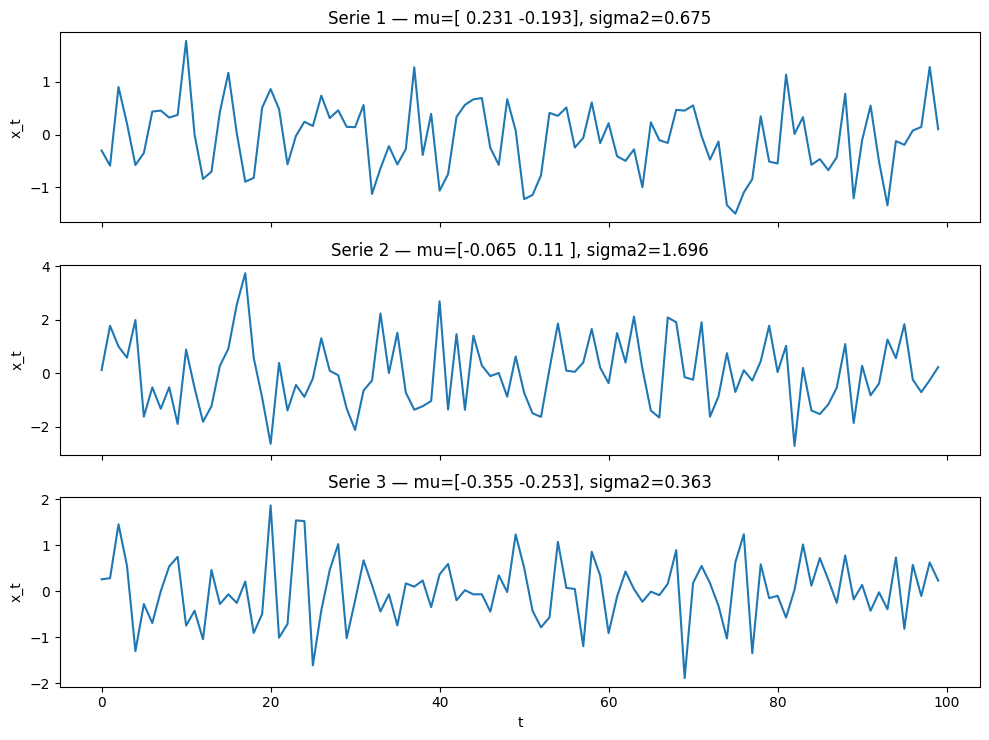

In [4]:
fig, axes = plt.subplots(n, 1, figsize=(10, 2.5*n), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(X_obs[j])
    ax.set_title(f'Serie {j+1} — mu={np.round(mu_true[j],3)}, sigma2={sigma2_true[j]:.3f}')
    ax.set_ylabel('x_t')
axes[-1].set_xlabel('t')
plt.tight_layout(); plt.show()


## 4. Log-vraisemblance exacte du MA(2) — version rapide

Pour un MA(2) centré, $x\sim\mathcal{N}(0,\Sigma)$ avec autocovariances :
$$\gamma_0=\sigma^2(1+\mu_1^2+\mu_2^2),\quad\gamma_1=\sigma^2\mu_1(1+\mu_2),\quad\gamma_2=\sigma^2\mu_2.$$

**Format lower-banded** attendu par `cholesky_banded` :
- ligne 0 : diagonale principale ($\gamma_0$)
- ligne 1 : première sous-diagonale ($\gamma_1$)
- ligne 2 : deuxième sous-diagonale ($\gamma_2$)

In [5]:
def ma2_loglik(mu, x, sigma2):
    """
    Log-vraisemblance exacte du MA(2) via cholesky_banded.
    Complexite O(T) en memoire et factorisation, speedup ~9x vs dense.
    """
    T = len(x); mu1, mu2 = mu
    g0 = sigma2 * (1.0 + mu1**2 + mu2**2)
    g1 = sigma2 * mu1 * (1.0 + mu2)
    g2 = sigma2 * mu2

    # Format lower-banded : ab[0]=diag, ab[1]=sous-diag 1, ab[2]=sous-diag 2
    ab      = np.zeros((3, T))
    ab[0, :]    = g0
    ab[1, :T-1] = g1
    ab[2, :T-2] = g2

    try:
        cb = cholesky_banded(ab, lower=True, check_finite=False)
    except np.linalg.LinAlgError:
        return -np.inf

    # log|Sigma| = 2 * sum(log(diag(L)))
    logdet = 2.0 * np.sum(np.log(cb[0]))
    z      = cho_solve_banded((cb, True), x, check_finite=False)
    return -0.5 * (T * np.log(2.0 * np.pi) + logdet + np.dot(x, z))


ll_test  = ma2_loglik(mu_true[0], X_obs[0], sigma2_true[0])
print(f'Log-vraisemblance serie 0 en la vraie valeur : {ll_test:.3f}')

# Verification de coherence vs Cholesky dense
from numpy.linalg import cholesky as _chol, solve as _solve
def _ma2_loglik_dense(mu, x, sigma2):
    T=len(x); mu1,mu2=mu
    g0=sigma2*(1+mu1**2+mu2**2); g1=sigma2*mu1*(1+mu2); g2=sigma2*mu2
    S=np.zeros((T,T)); i=np.arange(T)
    S[i,i]=g0; S[i[:-1],i[1:]]=S[i[1:],i[:-1]]=g1; S[i[:-2],i[2:]]=S[i[2:],i[:-2]]=g2
    L=_chol(S); return -0.5*(T*np.log(2*np.pi)+2*np.sum(np.log(np.diag(L)))+np.dot(_solve(L,x),_solve(L,x)))
ll_ref   = _ma2_loglik_dense(mu_true[0], X_obs[0], sigma2_true[0])
print(f'Verification (dense) : {ll_ref:.3f}  |  Ecart : {abs(ll_test-ll_ref):.2e}')

# Benchmark
import time
_x = X_obs[0]; _mu = mu_true[0]; _s2 = sigma2_true[0]; N_bench = 500
t0=time.perf_counter()
for _ in range(N_bench): ma2_loglik(_mu,_x,_s2)
t_fast=(time.perf_counter()-t0)/N_bench*1000
t0=time.perf_counter()
for _ in range(N_bench): _ma2_loglik_dense(_mu,_x,_s2)
t_dense=(time.perf_counter()-t0)/N_bench*1000
print(f'Banded : {t_fast:.3f} ms/appel   Dense : {t_dense:.3f} ms/appel   Speedup : {t_dense/t_fast:.1f}x')
n_calib = 5*2000*n
print(f'Calibration ({n_calib} appels) — estime : {n_calib*t_fast/1000:.1f}s (vs {n_calib*t_dense/1000:.1f}s dense)')


Log-vraisemblance serie 0 en la vraie valeur : -101.923
Verification (dense) : -101.923  |  Ecart : 1.42e-14
Banded : 0.040 ms/appel   Dense : 17.740 ms/appel   Speedup : 446.3x
Calibration (30000 appels) — estime : 1.2s (vs 532.2s dense)


## 5. Prior et log-posterior hiérarchique

### Support du prior sur $\mu_j$

La paramétrisation via $\beta$ impose :
$$\beta_1=\frac{\mu_2+1+2\mu_1}{4}>0,\quad\beta_2=\frac{\mu_2+1-2\mu_1}{4}>0,\quad\beta_3=\frac{1-\mu_2}{2}>0.$$


### Espace non contraint

Pour les variables positives ($\sigma_j^2$, $\alpha_k$, $\varsigma_k$), on travaille sur leur log. La log-posterior inclut les jacobiens : $\log|d\theta/d\phi|=\sum_j\log\sigma_j^2+\sum_k\log\alpha_k+\sum_k\log\varsigma_k$.

In [6]:
def beta_from_mu(mu):
    mu1, mu2 = mu
    return np.array([
        (mu2 + 1.0 + 2.0 * mu1) / 4.0,
        (mu2 + 1.0 - 2.0 * mu1) / 4.0,
        (1.0 - mu2) / 2.0
    ])


def in_support(mu):
    # Seules les 3 inequalites betai > 0 definissent le support.
    # La somme beta1+beta2+beta3 = 1 est automatique : inutile de la verifier.
    return bool(np.all(beta_from_mu(mu) > 0))


def log_posterior(params, X_obs, n):
    mu        = params[:2*n].reshape(n, 2)
    log_sig2  = params[2*n:3*n]
    log_alpha = params[3*n:3*n+3]
    log_s     = params[3*n+3:3*n+5]

    sigma2 = np.exp(log_sig2)
    alpha  = np.exp(log_alpha)
    s      = np.exp(log_s)

    # Prior alpha_k ~ Exp(1) + jacobien
    lp = -np.sum(alpha) + np.sum(log_alpha)
    # Prior s_k ~ HalfCauchy(1) + jacobien
    lp += np.sum(-np.log(1.0 + s**2) + log_s)

    log_B = np.sum(gammaln(alpha)) - gammaln(np.sum(alpha))

    for j in range(n):
        if not in_support(mu[j]):
            return -np.inf
        b = beta_from_mu(mu[j])
        # Prior beta_j ~ Dir(alpha) + jacobien |d(beta)/d(mu)| = 1/4
        lp += np.sum((alpha - 1.0) * np.log(b)) - log_B + np.log(0.25)
        # Prior sigma2_j ~ IG(s1,s2) + jacobien
        lp += invgamma.logpdf(sigma2[j], s[0], scale=s[1]) + log_sig2[j]
        ll = ma2_loglik(mu[j], X_obs[j], sigma2[j])
        if not np.isfinite(ll):
            return -np.inf
        lp += ll
    return lp


params_true = np.concatenate([
    mu_true.flatten(), np.log(sigma2_true),
    np.log(alpha_true), np.log(s_true)
])
lp_true = log_posterior(params_true, X_obs, n)
print(f'Dimension de phi : {len(params_true)}')
print(f'Log-posterior en la vraie valeur : {lp_true:.3f}')
print(f'Support OK : {np.isfinite(lp_true)}')

# Verification : la somme des beta est bien toujours 1 (identite algebrique)
for j in range(n):
    b = beta_from_mu(mu_true[j])
    print(f'  serie {j+1}: beta={np.round(b,4)}, sum={b.sum():.6f} (toujours 1)')


Dimension de phi : 14
Log-posterior en la vraie valeur : -375.154
Support OK : True
  serie 1: beta=[0.3175 0.0861 0.5964], sum=1.000000 (toujours 1)
  serie 2: beta=[0.245  0.3099 0.4451], sum=1.000000 (toujours 1)
  serie 3: beta=[0.0089 0.3644 0.6267], sum=1.000000 (toujours 1)


## 6. Initialisation depuis le prior

Chaque chaîne est initialisée en tirant un point depuis le prior. Cela garantit que le point de départ est dans le support et rend le diagnostic Gelman-Rubin plus robuste (les chaînes partent de régions différentes).

In [7]:
def sample_from_prior(rng, n, clip_s=(0.05, 20.0)):
    alpha_init = rng.exponential(1.0, size=3)
    s_init     = np.abs(rng.standard_cauchy(size=2))
    s_init     = np.clip(s_init, clip_s[0], clip_s[1])
    mus, sigs  = [], []
    for _ in range(n):
        beta   = rng.dirichlet(alpha_init)
        mu_j   = np.array([beta[0]-beta[1], 2*(beta[0]+beta[1])-1])
        sig2_j = np.clip(invgamma.rvs(s_init[0], scale=s_init[1], random_state=rng), 0.01, 200.0)
        mus.append(mu_j); sigs.append(sig2_j)
    return np.concatenate([
        np.array(mus).flatten(), np.log(np.array(sigs)),
        np.log(alpha_init), np.log(s_init)
    ])


rng_test = np.random.default_rng(0)
print('Verification : 5 tirages du prior (tous doivent avoir log_post fini)')
for _ in range(5):
    p  = sample_from_prior(rng_test, n)
    lp = log_posterior(p, X_obs, n)
    print(f'  log_post={lp:.2f}  (support={np.isfinite(lp)})')


Verification : 5 tirages du prior (tous doivent avoir log_post fini)
  log_post=-inf  (support=False)
  log_post=-2049.32  (support=True)
  log_post=-780.95  (support=True)
  log_post=-inf  (support=False)
  log_post=-815.80  (support=True)


## 7. Calibration du pas de la proposition

Pour un RWM de dimension $d$, le taux d'acceptation optimal est approximativement **23 %** (Roberts et al., 1997). On calibre en lançant 2 000 itérations depuis la vraie valeur.

In [8]:
def run_rwm(log_post_fn, theta_init, n_iter, step, rng):
    dim   = len(theta_init)
    theta = np.array(theta_init, dtype=float)
    lp    = log_post_fn(theta)
    samps = np.zeros((n_iter, dim))
    acc   = 0
    for i in range(n_iter):
        prop    = theta + rng.normal(0.0, step, size=dim)
        lp_prop = log_post_fn(prop)
        if np.log(rng.uniform()) < (lp_prop - lp):
            theta, lp = prop, lp_prop
            acc += 1
        samps[i] = theta
    return samps, acc / n_iter


log_post_fn = functools.partial(log_posterior, X_obs=X_obs, n=n)

print('Calibration du pas (2000 iterations depuis la vraie valeur) :')
for step_try in [0.04, 0.06, 0.08, 0.10, 0.12]:
    _, acc = run_rwm(log_post_fn, params_true, 2000, step_try, np.random.default_rng(99))
    marker = ' <-- cible ~23%' if 0.18 <= acc <= 0.30 else ''
    print(f'  step={step_try:.3f}  =>  acc={acc:.3f}{marker}')


Calibration du pas (2000 iterations depuis la vraie valeur) :
  step=0.040  =>  acc=0.499
  step=0.060  =>  acc=0.334
  step=0.080  =>  acc=0.206 <-- cible ~23%
  step=0.100  =>  acc=0.110
  step=0.120  =>  acc=0.064


## 8. Convergence : critère de Gelman-Rubin ($\hat{R}$)

On lance $M=4$ chaînes indépendantes initialisées **depuis le prior**. La convergence est jugée satisfaisante quand $\hat{R}<1.1$ pour toutes les dimensions.

$$\hat{R}=\sqrt{\frac{\hat{V}}{W}},\qquad\hat{V}=\left(1-\frac{1}{N}\right)W+\frac{B}{N}$$

avec $B$ la variance entre-chaînes et $W$ la variance intra-chaînes.

In [9]:
def gelman_rubin(chains):
    M      = len(chains)
    N      = chains[0].shape[0]
    means  = np.array([c.mean(0) for c in chains])
    grand  = means.mean(0)
    B      = N / (M-1) * np.sum((means - grand)**2, 0)
    W      = np.mean([c.var(0, ddof=1) for c in chains], 0)
    V_hat  = (1.0 - 1.0/N) * W + B / N
    return np.sqrt(V_hat / W)


rng_chains = np.random.default_rng(RNG_SEED + 1)
print(f'Lancement de {N_CHAINS} chaines x {N_ITER} iterations (dim={len(params_true)}, burnin={BURNIN})')

chains_raw, acc_rates = [], []
t_start = time.perf_counter()

for c in range(N_CHAINS):
    theta_init = sample_from_prior(rng_chains, n)
    samps, acc = run_rwm(log_post_fn, theta_init, N_ITER, STEP, rng_chains)
    chains_raw.append(samps); acc_rates.append(acc)
    print(f'  Chaine {c+1}/{N_CHAINS} — acc={acc:.3f}')

cpu_chains = time.perf_counter() - t_start
print(f'Temps total : {cpu_chains:.1f} s')


Lancement de 4 chaines x 10000 iterations (dim=14, burnin=3000)
  Chaine 1/4 — acc=0.201
  Chaine 2/4 — acc=0.147
  Chaine 3/4 — acc=0.200
  Chaine 4/4 — acc=0.198
Temps total : 14.8 s


In [10]:
post_chains = [c[BURNIN:] for c in chains_raw]
Rhat        = gelman_rubin(post_chains)

dim_labels = (
    [f'mu{j+1}_{k+1}' for j in range(n) for k in range(2)]
    + [f'log_sig2_{j+1}' for j in range(n)]
    + ['log_a1','log_a2','log_a3','log_s1','log_s2']
)

df_rhat = pd.DataFrame({'parametre': dim_labels, 'R_hat': np.round(Rhat, 4)})
print(df_rhat.to_string(index=False))
print(f'R-hat max  : {Rhat.max():.4f}')
print(f'R-hat mean : {Rhat.mean():.4f}')
print(f'Convergence (R-hat < 1.1) : {(Rhat < 1.1).all()}')


 parametre  R_hat
     mu1_1 1.0274
     mu1_2 1.0023
     mu2_1 1.0033
     mu2_2 1.0044
     mu3_1 1.0394
     mu3_2 1.0050
log_sig2_1 1.0038
log_sig2_2 1.0013
log_sig2_3 1.0111
    log_a1 1.2522
    log_a2 1.0087
    log_a3 1.0157
    log_s1 1.0985
    log_s2 1.1896
R-hat max  : 1.2522
R-hat mean : 1.0473
Convergence (R-hat < 1.1) : False


/tmp/ipykernel_13137/3590961349.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dim_labels, rotation=45, ha='right')


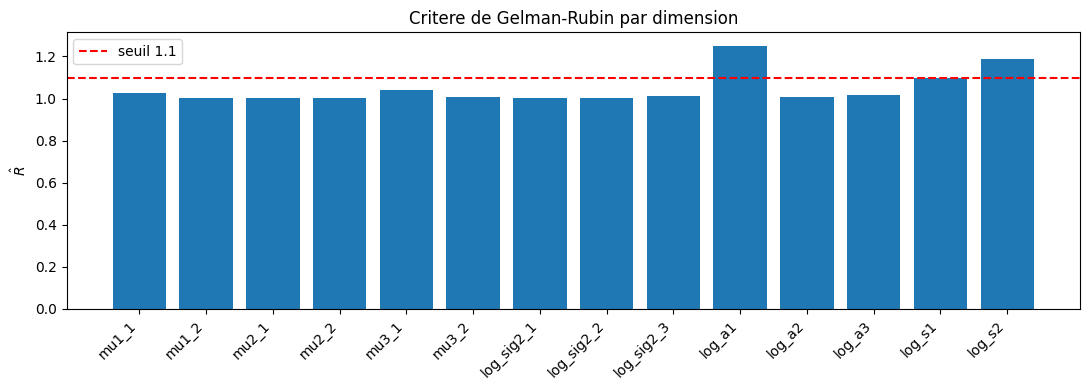

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(dim_labels, Rhat)
ax.axhline(1.1, color='red', linestyle='--', label='seuil 1.1')
ax.set_ylabel(r'$\hat{R}$')
ax.set_title('Critere de Gelman-Rubin par dimension')
ax.set_xticklabels(dim_labels, rotation=45, ha='right')
ax.legend(); plt.tight_layout(); plt.show()


## 9. Traceplots

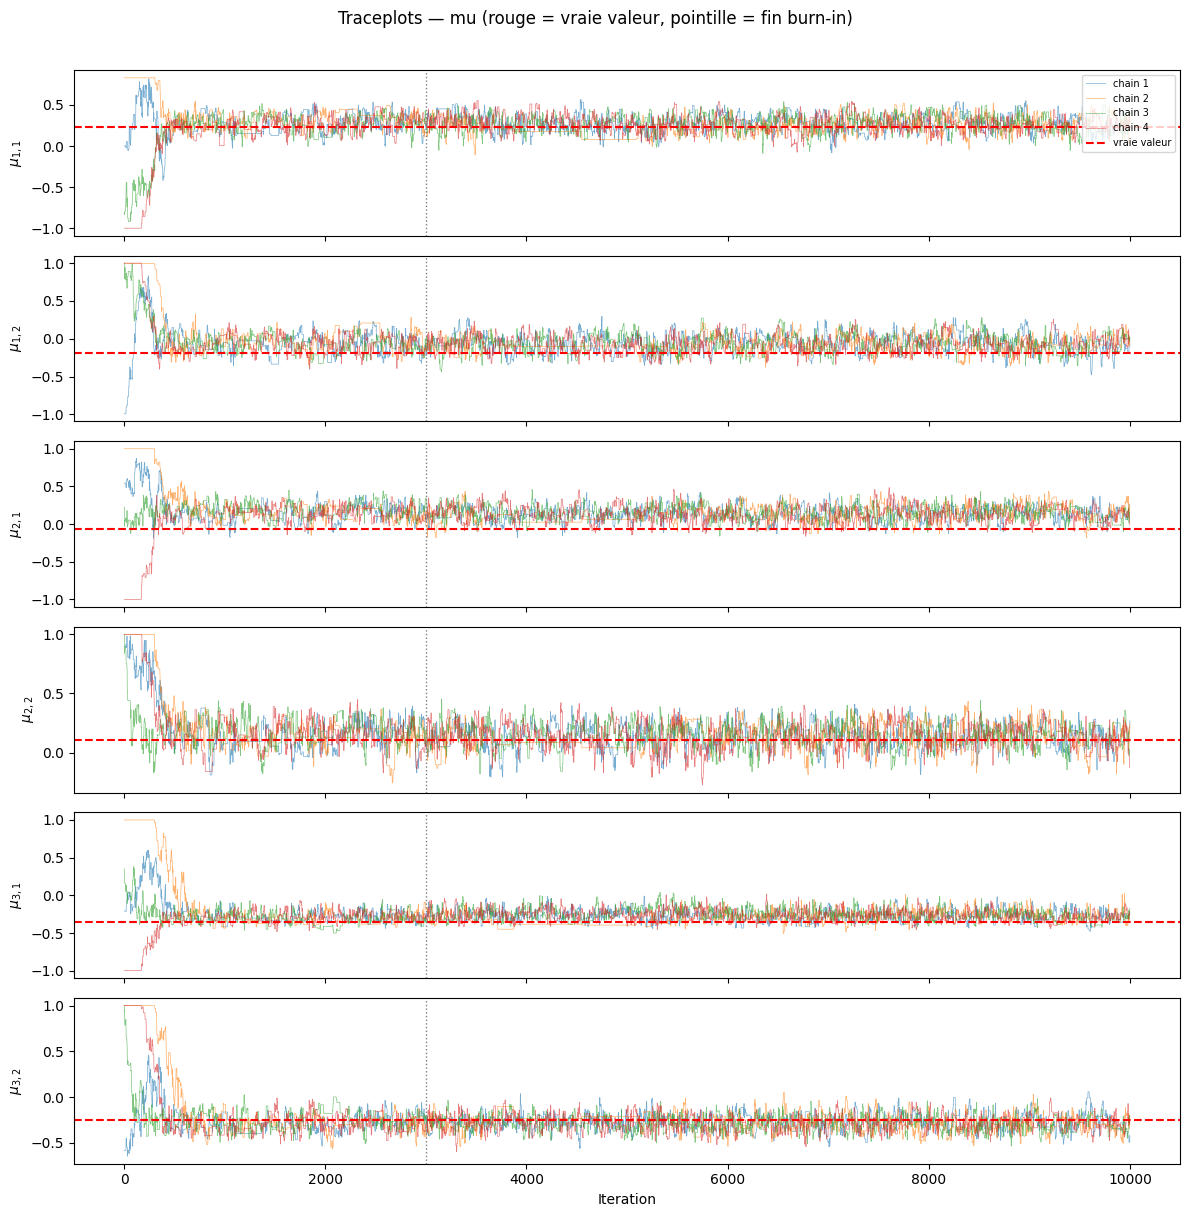

In [12]:
mu_idx = list(range(2*n))
fig, axes = plt.subplots(len(mu_idx), 1, figsize=(12, 2.0*len(mu_idx)), sharex=True)
for ax, idx in zip(axes, mu_idx):
    j, k = divmod(idx, 2)
    for c, chain in enumerate(chains_raw):
        ax.plot(chain[:, idx], alpha=0.6, linewidth=0.5, label=f'chain {c+1}')
    ax.axhline(mu_true.flatten()[idx], color='red', lw=1.5, ls='--', label='vraie valeur')
    ax.axvline(BURNIN, color='gray', ls=':', lw=1)
    ax.set_ylabel(rf'$\mu_{{{j+1},{k+1}}}$')
axes[0].legend(loc='upper right', fontsize=7)
axes[-1].set_xlabel('Iteration')
plt.suptitle('Traceplots — mu (rouge = vraie valeur, pointille = fin burn-in)', y=1.01)
plt.tight_layout(); plt.show()


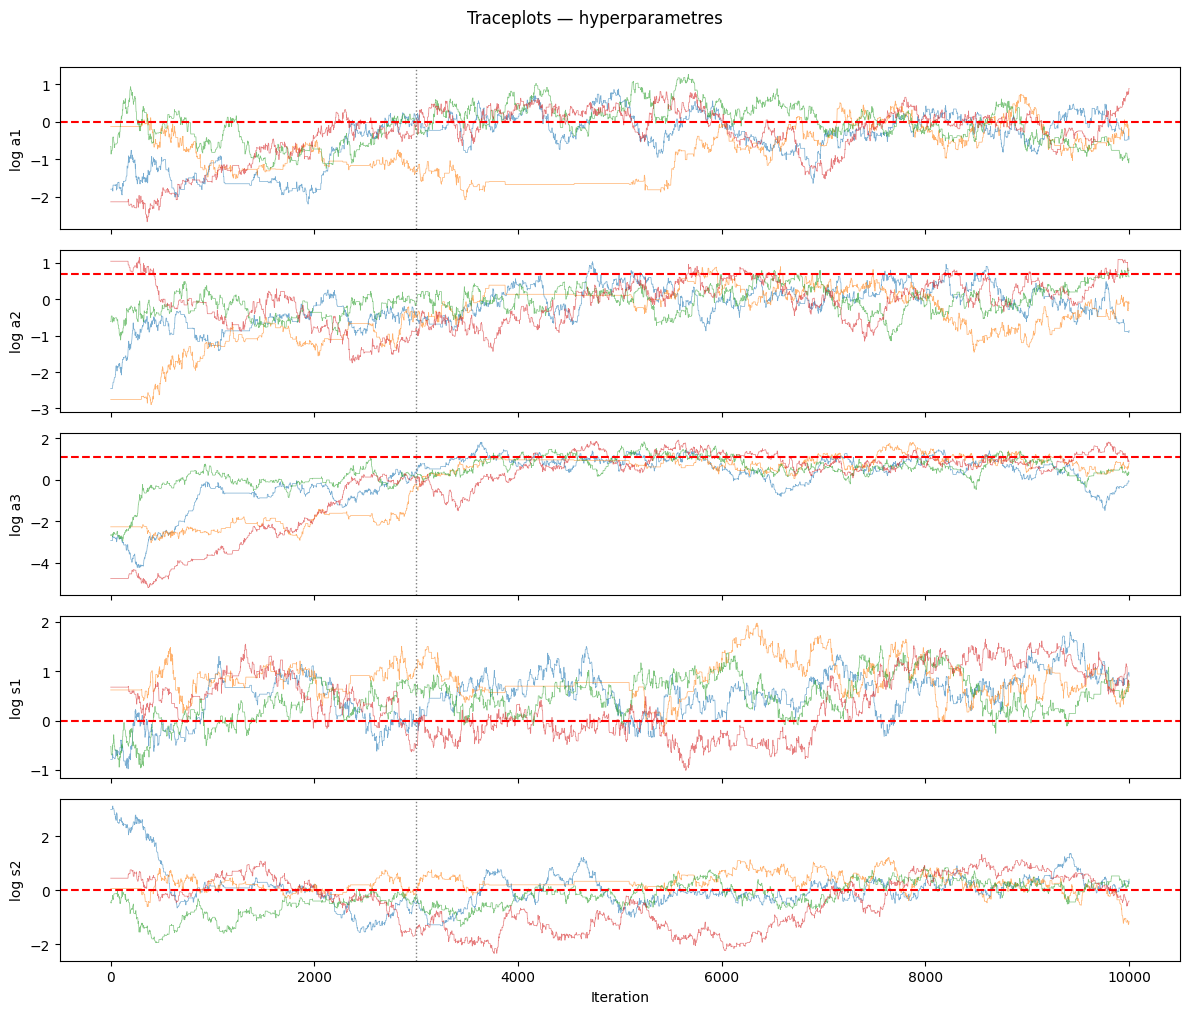

In [13]:
hyp_idx  = list(range(3*n, 3*n+5))
hyp_lbls = ['log a1','log a2','log a3','log s1','log s2']
hyp_true = np.concatenate([np.log(alpha_true), np.log(s_true)])
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, idx, lbl, tv in zip(axes, hyp_idx, hyp_lbls, hyp_true):
    for c, chain in enumerate(chains_raw):
        ax.plot(chain[:, idx], alpha=0.6, linewidth=0.5)
    ax.axhline(tv, color='red', lw=1.5, ls='--')
    ax.axvline(BURNIN, color='gray', ls=':', lw=1)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('Iteration')
plt.suptitle('Traceplots — hyperparametres', y=1.01)
plt.tight_layout(); plt.show()


## 10. Densités marginales postérieures

On fusionne les $M$ chaînes post burn-in pour obtenir un échantillon de la posterior.

Echantillon posterior combine : 28000 points


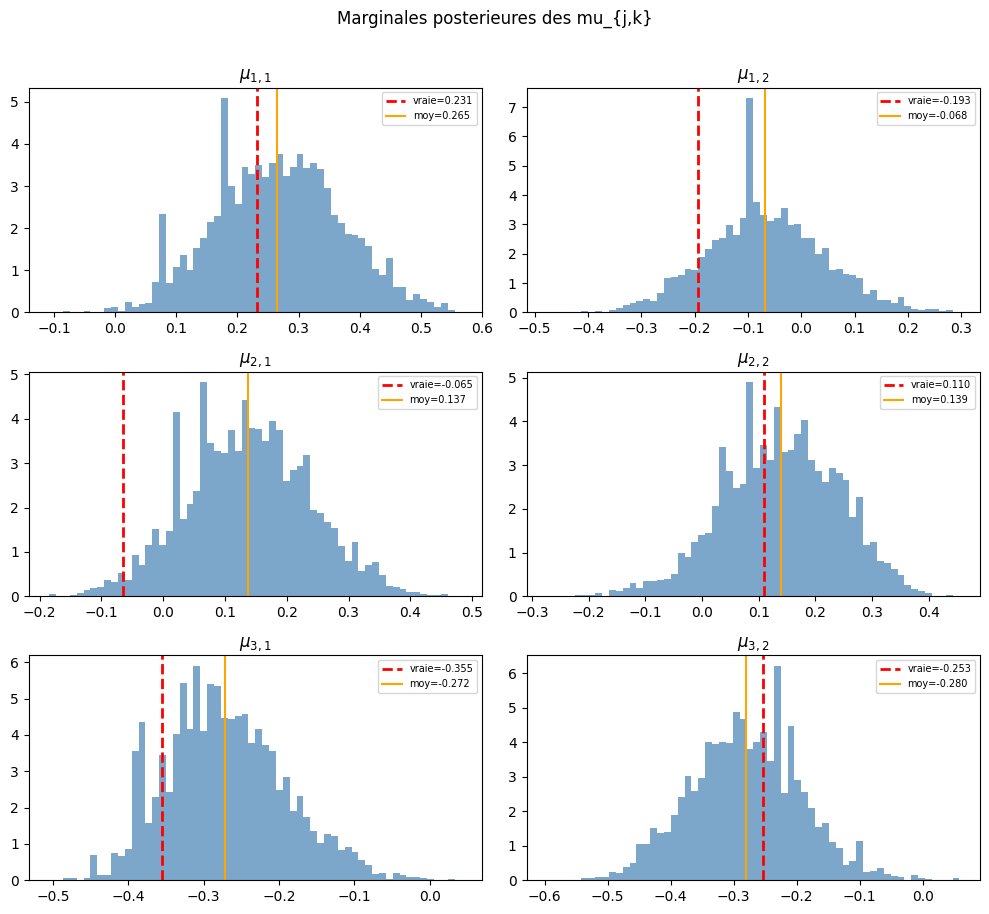

In [14]:
post_all = np.concatenate(post_chains, axis=0)
print(f'Echantillon posterior combine : {post_all.shape[0]} points')

fig, axes = plt.subplots(n, 2, figsize=(10, 3*n))
for j in range(n):
    for k, ax in enumerate(axes[j]):
        idx = 2*j+k
        ax.hist(post_all[:, idx], bins=60, density=True, alpha=0.7, color='steelblue')
        ax.axvline(mu_true[j,k], color='red', lw=2, ls='--', label=f'vraie={mu_true[j,k]:.3f}')
        ax.axvline(post_all[:,idx].mean(), color='orange', lw=1.5,
                   label=f'moy={post_all[:,idx].mean():.3f}')
        ax.set_title(rf'$\mu_{{{j+1},{k+1}}}$'); ax.legend(fontsize=7)
plt.suptitle('Marginales posterieures des mu_{j,k}', y=1.01)
plt.tight_layout(); plt.show()


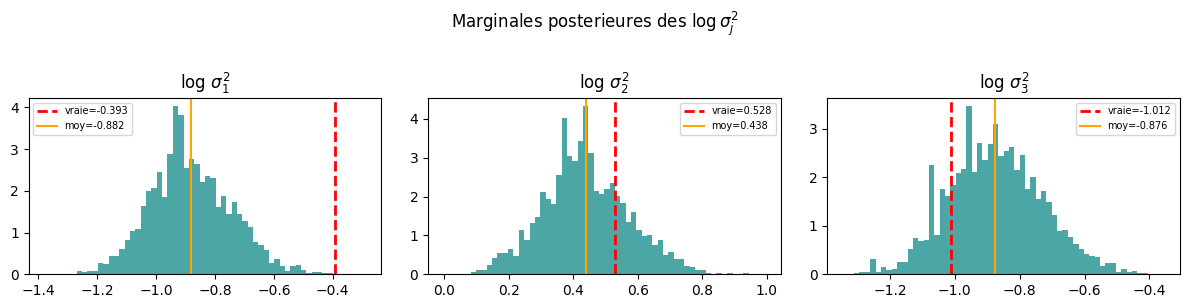

In [15]:
fig, axes = plt.subplots(1, n, figsize=(4*n, 3))
for j, ax in enumerate(axes):
    idx = 2*n+j
    ax.hist(post_all[:, idx], bins=60, density=True, alpha=0.7, color='teal')
    ax.axvline(np.log(sigma2_true[j]), color='red', lw=2, ls='--',
               label=f'vraie={np.log(sigma2_true[j]):.3f}')
    ax.axvline(post_all[:,idx].mean(), color='orange', lw=1.5,
               label=f'moy={post_all[:,idx].mean():.3f}')
    ax.set_title(rf'$\log\,\sigma^2_{{{j+1}}}$'); ax.legend(fontsize=7)
plt.suptitle(r'Marginales posterieures des $\log\sigma^2_j$', y=1.01)
plt.tight_layout(); plt.show()


## 11. ESS, erreur inférentielle et erreur Monte Carlo

- **ESS** : taille d'échantillon iid équivalent (via autocorrélation, coupure au premier lag négatif).
- **Erreur inférentielle** : $\|\hat{\mu}-\mu^*\|_2$ sur les paramètres $\mu_j$.
- **Erreur Monte Carlo** : variabilité des estimations entre runs indépendants sur les mêmes données.

In [16]:
def ess_1d(x):
    x   = np.asarray(x, float) - np.mean(x)
    N   = len(x)
    var = np.dot(x,x)/N
    if var == 0: return float(N)
    ml  = min(1000, N-1)
    acf = np.empty(ml+1); acf[0] = 1.0
    for lag in range(1, ml+1):
        acf[lag] = np.dot(x[:-lag], x[lag:]) / ((N-lag)*var)
    cut = np.where(acf[1:] < 0)[0]
    m   = cut[0]+1 if len(cut) > 0 else ml
    tau = 1.0 + 2.0*np.sum(acf[1:m])
    return N/tau if tau > 0 else float(N)


def summarize_post(post_samp, mu_true_flat):
    mu_idx  = np.arange(2*n)
    mean    = post_samp.mean(0)
    sd      = post_samp.std(0)
    ess     = np.array([ess_1d(post_samp[:,i]) for i in mu_idx])
    inf_err = np.linalg.norm(mean[mu_idx] - mu_true_flat)
    return mean, sd, ess, inf_err


mean_all, sd_all, ess_all, inf_err_all = summarize_post(post_all, mu_true.flatten())
print('Resume posterior combine (post burn-in, toutes chaines)')
print(f'  mu_true   : {np.round(mu_true.flatten(),4)}')
print(f'  post mean : {np.round(mean_all[:2*n],4)}')
print(f'  post sd   : {np.round(sd_all[:2*n],4)}')
print(f'  ESS (mu)  : {np.round(ess_all,0).astype(int)}')
print(f'  Err. inf. ||mu_hat - mu_true|| : {inf_err_all:.4f}')


Resume posterior combine (post burn-in, toutes chaines)
  mu_true   : [ 0.2313 -0.1928 -0.0649  0.1097 -0.3555 -0.2534]
  post mean : [ 0.2653 -0.0677  0.1369  0.1385 -0.2719 -0.2803]
  post sd   : [0.1034 0.1096 0.0997 0.1021 0.0797 0.0877]
  ESS (mu)  : [130 493 300 386  84 713]
  Err. inf. ||mu_hat - mu_true|| : 0.2570


## 12. Répétitions Monte Carlo

On relance le RWM $N_{\text{rep}}$ fois sur les **mêmes données** $x^*$. Cela quantifie l'erreur purement numérique de l'algorithme.

Métriques qui seront la **référence** lors de la comparaison avec ABC et ABC-Gibbs.

In [17]:
results_mc = []
rng_mc     = np.random.default_rng(RNG_SEED + 100)
print(f'Repetitions MC : {N_REP} runs x {N_ITER} iterations')

for r in range(N_REP):
    theta_init      = sample_from_prior(rng_mc, n)
    t0              = time.perf_counter()
    samps, acc      = run_rwm(log_post_fn, theta_init, N_ITER, STEP, rng_mc)
    elapsed         = time.perf_counter() - t0
    m, s, e, ie     = summarize_post(samps[BURNIN:], mu_true.flatten())
    results_mc.append({
        'rep'           : r+1,
        **{f'mean_mu{j+1}_{k+1}': m[2*j+k] for j in range(n) for k in range(2)},
        'inf_error'     : ie,
        'ess_min'       : e.min(),
        'ess_mean'      : e.mean(),
        'acceptance'    : acc,
        'cpu_s'         : elapsed,
    })
    print(f'  Rep {r+1:2d}/{N_REP} — acc={acc:.3f}  inf_err={ie:.4f}  ESS_min={e.min():.0f}')

df_mc = pd.DataFrame(results_mc)


Repetitions MC : 10 runs x 10000 iterations
  Rep  1/10 — acc=0.158  inf_err=0.2677  ESS_min=31
  Rep  2/10 — acc=0.204  inf_err=0.2620  ESS_min=57
  Rep  3/10 — acc=0.191  inf_err=0.2677  ESS_min=84
  Rep  4/10 — acc=0.195  inf_err=0.2638  ESS_min=44
  Rep  5/10 — acc=0.197  inf_err=0.2818  ESS_min=69
  Rep  6/10 — acc=0.197  inf_err=0.2684  ESS_min=101
  Rep  7/10 — acc=0.219  inf_err=0.2777  ESS_min=50
  Rep  8/10 — acc=0.200  inf_err=0.2847  ESS_min=50
  Rep  9/10 — acc=0.216  inf_err=0.2731  ESS_min=103
  Rep 10/10 — acc=0.200  inf_err=0.2768  ESS_min=81


In [18]:
print('\nStatistiques des repetitions Monte Carlo :')
print(df_mc.describe().round(4).to_string())



Statistiques des repetitions Monte Carlo :
           rep  mean_mu1_1  mean_mu1_2  mean_mu2_1  mean_mu2_2  mean_mu3_1  mean_mu3_2  inf_error   ess_min  ess_mean  acceptance    cpu_s
count  10.0000     10.0000     10.0000     10.0000     10.0000     10.0000     10.0000    10.0000   10.0000   10.0000     10.0000  10.0000
mean    5.5000      0.2811     -0.0672      0.1458      0.1489     -0.2649     -0.2852     0.2724   66.9668  134.9346      0.1975   3.7046
std     3.0277      0.0203      0.0070      0.0067      0.0107      0.0162      0.0094     0.0077   24.6166   22.2982      0.0164   0.1846
min     1.0000      0.2484     -0.0824      0.1372      0.1398     -0.2825     -0.2935     0.2620   30.8368   97.1272      0.1583   3.4352
25%     3.2500      0.2670     -0.0697      0.1418      0.1427     -0.2771     -0.2925     0.2677   49.8016  117.4054      0.1952   3.5452
50%     5.5000      0.2817     -0.0653      0.1454      0.1459     -0.2691     -0.2877     0.2707   62.9617  144.4030     

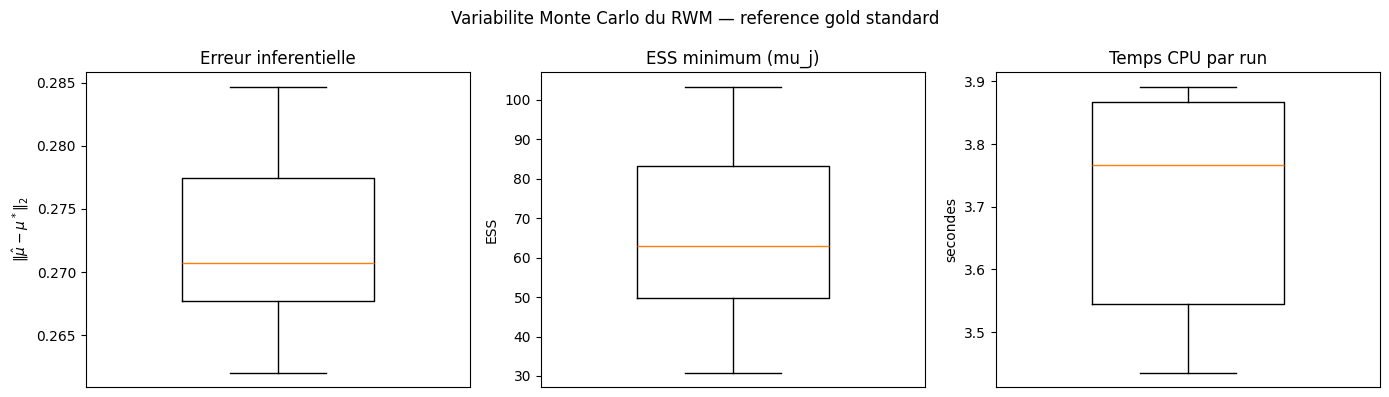

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].boxplot(df_mc['inf_error'], widths=0.5)
axes[0].set_title('Erreur inferentielle')
axes[0].set_ylabel(r'$\|\hat{\mu}-\mu^*\|_2$')
axes[0].set_xticks([])

axes[1].boxplot(df_mc['ess_min'], widths=0.5)
axes[1].set_title('ESS minimum (mu_j)')
axes[1].set_ylabel('ESS'); axes[1].set_xticks([])

axes[2].boxplot(df_mc['cpu_s'], widths=0.5)
axes[2].set_title('Temps CPU par run')
axes[2].set_ylabel('secondes'); axes[2].set_xticks([])

plt.suptitle('Variabilite Monte Carlo du RWM — reference gold standard')
plt.tight_layout(); plt.show()


### 12b. Évaluation détaillée de l'erreur numérique par composante

Trois niveaux d'évaluation des erreurs numériques des estimates:

1. **Erreur par composante** $\mu_{j,k}$ : montre si l'erreur est concentrée sur certains paramètres.
2. **Stabilité par rapport au burn-in** : vérifie que la variabilité observée vient du hasard Monte Carlo et non d'une convergence incomplète.
3. **Erreur relative au prior** : l'algorithme apporte-t-il vraiment de l'information par rapport au prior ?

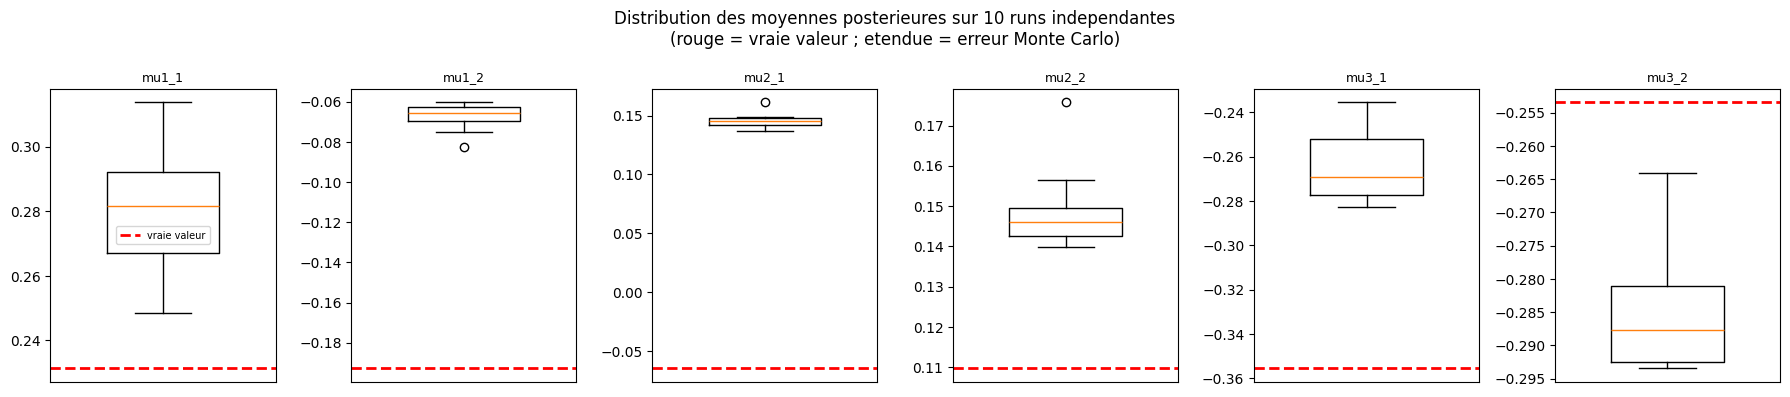

Biais moyen par composante (mean_post - true) :
  mean_mu1_1: biais=+0.0497, std MC=0.0203
  mean_mu1_2: biais=+0.1255, std MC=0.0070
  mean_mu2_1: biais=+0.2106, std MC=0.0067
  mean_mu2_2: biais=+0.0392, std MC=0.0107
  mean_mu3_1: biais=+0.0906, std MC=0.0162
  mean_mu3_2: biais=-0.0317, std MC=0.0094


In [20]:
# ── 1. Boxplots des estimées par composante mu_{j,k} ─────────────────────────
mu_keys = [f'mean_mu{j+1}_{k+1}' for j in range(n) for k in range(2)]
mu_true_flat = mu_true.flatten()

fig, axes = plt.subplots(1, len(mu_keys), figsize=(3*len(mu_keys), 4))
for ax, key, tv in zip(axes, mu_keys, mu_true_flat):
    ax.boxplot(df_mc[key], widths=0.5)
    ax.axhline(tv, color='red', lw=2, ls='--', label='vraie valeur')
    ax.set_title(key.replace('mean_',''), fontsize=9)
    ax.set_xticks([])
axes[0].legend(fontsize=7)
plt.suptitle(
    f'Distribution des moyennes posterieures sur {N_REP} runs independantes\n'
    '(rouge = vraie valeur ; etendue = erreur Monte Carlo)'
)
plt.tight_layout()
plt.show()

# Commentaire quantitatif
print('Biais moyen par composante (mean_post - true) :')
for key, tv in zip(mu_keys, mu_true_flat):
    bias = df_mc[key].mean() - tv
    std  = df_mc[key].std()
    print(f'  {key}: biais={bias:+.4f}, std MC={std:.4f}')


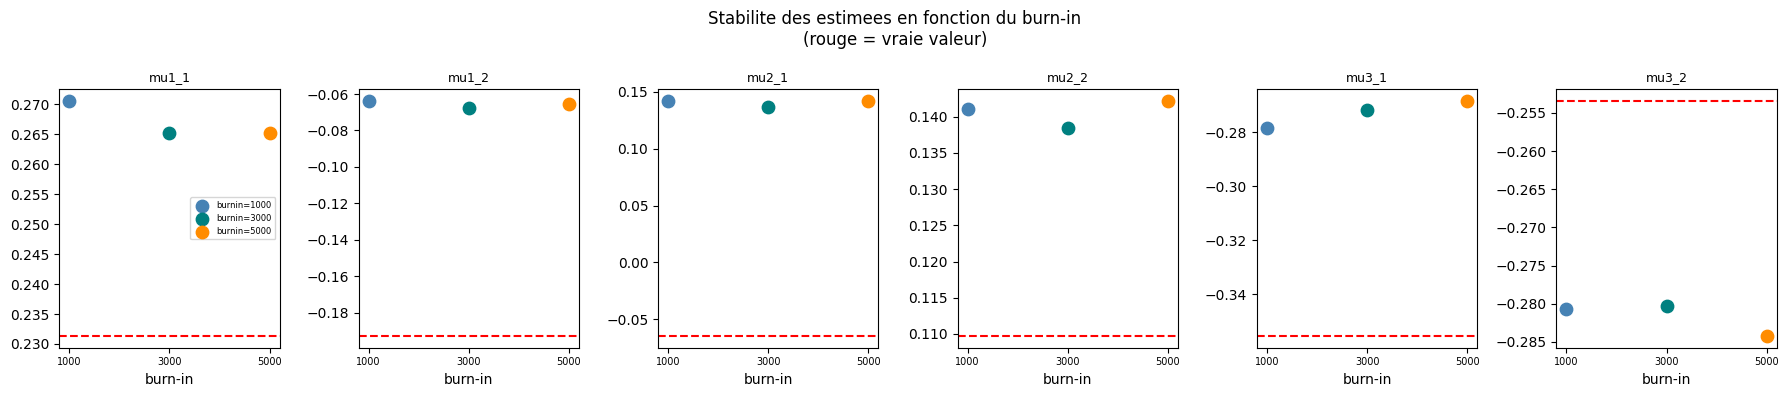

Variation max entre burnin=1000 et burnin=5000 par composante :
  mean_mu1_1: 0.0054
  mean_mu1_2: 0.0019
  mean_mu2_1: 0.0001
  mean_mu2_2: 0.0011
  mean_mu3_1: 0.0099
  mean_mu3_2: 0.0035


In [21]:
# ── 2. Stabilite par rapport au burn-in ──────────────────────────────────────
# On reuse les chaines deja calculees (chains_raw) et on compare
# les estimees pour trois valeurs de burn-in differentes
burnin_values = [1000, 3000, 5000]
results_burnin = {}

for bi in burnin_values:
    post_bi = np.concatenate([c[bi:] for c in chains_raw], axis=0)
    means_bi = post_bi[:, :2*n].mean(axis=0)
    results_burnin[bi] = means_bi

fig, axes = plt.subplots(1, len(mu_keys), figsize=(3*len(mu_keys), 4))
colors = ['steelblue', 'teal', 'darkorange']
for ax, idx, tv in zip(axes, range(len(mu_keys)), mu_true_flat):
    for bi, col in zip(burnin_values, colors):
        ax.scatter([bi], [results_burnin[bi][idx]], color=col,
                   s=80, zorder=3, label=f'burnin={bi}')
    ax.axhline(tv, color='red', lw=1.5, ls='--')
    ax.set_title(mu_keys[idx].replace('mean_',''), fontsize=9)
    ax.set_xticks(burnin_values)
    ax.set_xticklabels([str(b) for b in burnin_values], fontsize=7)
    ax.set_xlabel('burn-in')
if len(axes) > 0:
    axes[0].legend(fontsize=6)
plt.suptitle('Stabilite des estimees en fonction du burn-in\n(rouge = vraie valeur)')
plt.tight_layout()
plt.show()

# Si les points sont alignes horizontalement -> burn-in de 3000 est suffisant
print('Variation max entre burnin=1000 et burnin=5000 par composante :')
for idx, key in enumerate(mu_keys):
    delta = abs(results_burnin[1000][idx] - results_burnin[5000][idx])
    print(f'  {key}: {delta:.4f}')


In [22]:
# ── 3. Erreur relative au prior : le RWM apporte-t-il de l'information ? ─────
# On compare l'erreur inférentielle du RWM à celle qu'on obtiendrait
# en utilisant simplement la moyenne du prior comme estimateur

# Moyenne du prior sur mu_j : E[beta1-beta2] = 0 car Dir(alpha) est symetrique
# et E[2(beta1+beta2)-1] = 2*(alpha1+alpha2)/sum(alpha) - 1
alpha_prior_mean = np.array([1.0, 1.0, 1.0])  # prior non-informatif
mu_prior_mean = np.array([
    alpha_prior_mean[0] - alpha_prior_mean[1],
    2*(alpha_prior_mean[0]+alpha_prior_mean[1])/sum(alpha_prior_mean) - 1
])
mu_prior_flat = np.tile(mu_prior_mean, n)

prior_err  = np.linalg.norm(mu_prior_flat - mu_true_flat)
rwm_err    = df_mc['inf_error'].mean()
print(f'Erreur si on utilise la moyenne du prior : {prior_err:.4f}')
print(f'Erreur RWM (moyenne sur {N_REP} runs)    : {rwm_err:.4f}')
print(f'Reduction d erreur apportee par RWM      : {(1-rwm_err/prior_err)*100:.1f}%')

# Synthese finale des erreurs numeriques
print('\n=== SYNTHESE ERREUR NUMERIQUE DU GOLD STANDARD ===')
print(f'  Erreur MC (std inter-runs) : {df_mc["inf_error"].std():.4f}')
print(f'  Erreur MC (IQR)            : '
      f'{df_mc["inf_error"].quantile(0.75)-df_mc["inf_error"].quantile(0.25):.4f}')
print(f'  ESS median                 : {df_mc["ess_min"].median():.0f}')
print(f'  Taux acceptation median    : {df_mc["acceptance"].median():.3f}')
print(f'  CPU median (s)             : {df_mc["cpu_s"].median():.1f}')
print('Ces valeurs serviront de reference pour la comparaison avec ABC et ABC-Gibbs.')


Erreur si on utilise la moyenne du prior : 0.9248
Erreur RWM (moyenne sur 10 runs)    : 0.2724
Reduction d erreur apportee par RWM      : 70.5%

=== SYNTHESE ERREUR NUMERIQUE DU GOLD STANDARD ===
  Erreur MC (std inter-runs) : 0.0077
  Erreur MC (IQR)            : 0.0098
  ESS median                 : 63
  Taux acceptation median    : 0.198
  CPU median (s)             : 3.8
Ces valeurs serviront de reference pour la comparaison avec ABC et ABC-Gibbs.


## 13. Export du gold standard

On sauvegarde dans `gold_standard_rwm.npz` tous les objets nécessaires à la comparaison :

| Objet | Contenu |
|---|---|
| `X_obs` | Données observées partagées |
| `mu_true`, `sigma2_true` | Vrais paramètres |
| `alpha_true`, `s_true` | Vrais hyperparamètres |
| `post_all` | Échantillon posterior RWM fusionné |
| `Rhat` | Critère de Gelman-Rubin |

Permet de s'assurer que dans les notebooks ABC-reject et ABC-Gibbs  **toutes les méthodes travaillent sur les mêmes données $x^*$**.

In [23]:
np.savez(
    'gold_standard_rwm.npz',
    X_obs       = np.array(X_obs),
    mu_true     = mu_true,
    sigma2_true = sigma2_true,
    alpha_true  = alpha_true,
    s_true      = s_true,
    post_all    = post_all,
    Rhat        = Rhat,
    dim_labels  = dim_labels,
    n           = np.array([n]),
    T_len       = np.array([T_len]),
)
print('Sauvegarde gold_standard_rwm.npz')
print(f'  post_all shape : {post_all.shape}')
print(f'  R-hat max      : {Rhat.max():.4f}')


Sauvegarde gold_standard_rwm.npz
  post_all shape : (28000, 14)
  R-hat max      : 1.2522


## 14. Récapitulatif — métriques à reporter

| Méthode | CPU (s) | Inf. error | ESS min | Acc. rate |
|---|---|---|---|---|
| **RWM (gold std)** | cf. ci-dessus | — | — | ~23 % |
| ABC-reject | à faire | à faire | — | — |
| ABC-Gibbs | à faire | à faire | — | — |

**Note** : l'erreur inférentielle d'ABC-reject et ABC-Gibbs se mesure comme la distance entre leur moyenne posterior et celle du RWM (ou directement à $\mu^*$). Le CPU time doit être comparé à budget de simulation équivalent.